##  Quality control for 2D ice sheet model output data

Here we show what kind of quality check should be done for each model with the example PIK_PISM.

In [1]:
import numpy as np
import xarray as xr
from matplotlib import pylab as plt
import pandas as pd

In [32]:
pth_model = '/Volumes/Crucial X8/IMSIP6_2300/PIK_PISM'
exp='expAE02_8'
mask_floating='sftflf_AIS_PIK_PISM_expAE02.nc'
draft = 'base_AIS_PIK_PISM_expAE02.nc'
bmb_output = 'libmassbffl_AIS_PIK_PISM_expAE02.nc'
pth_scalar_values = '/Users/jbec0008/SAEF/ISMIP_2300/ComputedScalars/expAE02/'
smb = 'acabf_AIS_PIK_PISM_expAE02.nc'
bed ='topg_AIS_PIK_PISM_expAE02.nc'


# Check floating mask

In [8]:
d =xr.open_dataset(pth_model +'/'+exp +'/'+mask_floating)

/Users/jbec0008/python-virtual-environments/vpyplus/lib/python3.9/site-packages/xarray/coding/times.py:710: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


### 1. Is grid equi distant?


In [9]:
dx_array =d.x.values[1:]-d.x.values[:-1]
dx= np.unique(dx_array)
if len(dx)==1:
    
    print('yes x resolution of ',dx )
else:
    print('WOOOOOPS!')
dy_array =d.y.values[1:]-d.y.values[:-1]
dy = np.unique(dy_array)
if len(dy)==1:
 
    print('yes y resolution of ',dy )
else:
    print('WOOOOOPS!')
dx=dx[0]
dy=dy[0]

yes x resolution of  [8000.]
yes y resolution of  [8000.]


### 2. Show me the shelf areas

Text(0.5, 1.0, '2301-01-01')

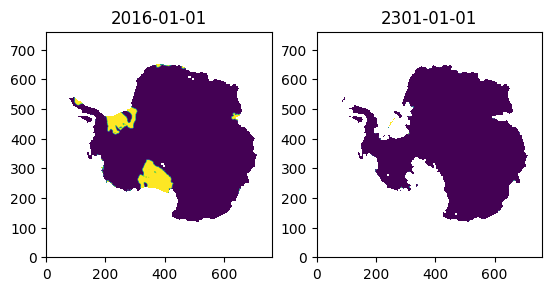

In [10]:
f, ax = plt.subplots(1,2)
i_0=0
i_end = -1

ax[0].imshow(d.sftflf.values[i_0,],origin ='lower')
ax[0].set_title(d.time.values[i_0].strftime().split(' ')[0])

ax[1].imshow(d.sftflf.values[i_end,],origin ='lower')
ax[1].set_title(d.time.values[i_end].strftime().split(' ')[0])

### 3. Are there partially floating cells?

In [24]:
np.unique(d.sftflf.values[i_end,])


array([0.0000000e+00, 3.9484486e-18, 1.1800478e-17, ..., 9.9994731e-01,
       1.0000000e+00,           nan], dtype=float32)

Yes not only 1,0 and nans!

### TODO: is that correct with  the `metadata.txt`?

### 4. calc shelf area timeline and compare to seroussi data set

In [34]:
#load aggregated values seroussi et al:
d2 =xr.open_dataset(pth_scalar_values +'iareafl/computed_iareafl_AIS_PIK_PISM_expAE02.nc',decode_times=False )

In [35]:
fl_arae_with_partiallyfloating =np.zeros(d.time.size)
fl_arae_with_onlyfloating =np.zeros(d.time.size)

years = np.zeros(d.time.size)
for i in range(d.time.size):
    fl_arae_with_partiallyfloating[i]= np.nansum(d.sftflf.values[i,])*dx*dy

    years[i]=int(d.time.values[i].strftime().split('-')[0])


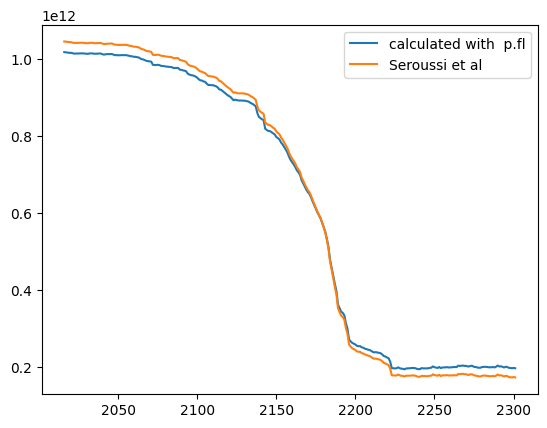

In [36]:
plt.plot(years,fl_arae_with_partiallyfloating, label='calculated with  p.fl')
# plt.plot(years,fl_arae_with_onlyfloating, label='calculated with  fl only')

plt.plot(years,d2.iareafl.values, label='Seroussi et al')
plt.legend()


Did not check why this is different , check Helens script as a potential todo!

### 4.  Is ice shelf draft negative for floting mask?

In [37]:
d_draft =xr.open_dataset(pth_model +'/'+exp +'/'+draft)

/Users/jbec0008/python-virtual-environments/vpyplus/lib/python3.9/site-packages/xarray/coding/times.py:710: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


Text(0, 0.5, 'thk (m)')

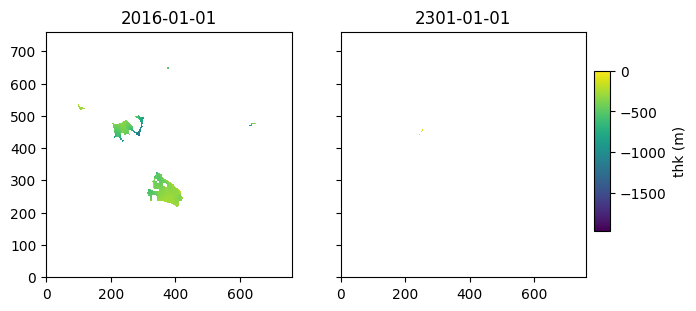

In [38]:
### plot ice shelf draft 
inds =[0,-1]

f, ax = plt.subplots(1,len(inds), figsize = (8,8),sharey =True)
for i,ind in enumerate(inds):
    m_in=d.sftflf.values[ind,]
    m = m_in ==1
    shelf_draft =d_draft.base.values[ind,]
    shelf_draft[~m]=np.nan
    im =ax[i].imshow(shelf_draft,origin ='lower')
    ax[i].set_title(d.time.values[ind].strftime().split(' ')[0])
    


f.subplots_adjust(right=0.8)

cbar_ax = f.add_axes([0.81, 0.4, 0.02, 0.2])
f.colorbar(im, cax=cbar_ax)
cbar_ax.set_ylabel('thk (m)')



In [39]:
for i in range(d.time.size):
    m_in=d.sftflf.values[i,]
    m = m_in ==1
    shelf_draft =d_draft.base.values[i,]
    mpos = shelf_draft[m]>0
    if mpos.sum()>0:
        print('WOOPS base is actually grounded at ' ,years[i])


###  5.  is there BMB negative or postifve ?

In [40]:
d_bmb=xr.open_dataset(pth_model +'/'+exp +'/'+bmb_output)
bmb = d_bmb.libmassbffl.values[0,]
print('negative?',np.nanmin(bmb))
print('positive?',np.nanmax(bmb))

negative? -0.0011520812
positive? 4.3234904e-05


there is a bit refreezing,ok. Melting is negative

### 5. is there BMB on grounded cells ?

In [41]:
for i in range(d.time.size):
    m_in=d.sftflf.values[i,]
    m = m_in ==0
    bmb_grounded=d_bmb.libmassbffl.values[i,]
    mpos = bmb_grounded[m]>0
    if mpos.sum()>0:
        print('WOOPS melting at fully grounded cells ' ,years[i])


  etc..

## TODO: Next steps.
- Check whether there is melting at partially floating cells. Check whether this is  consitent with `metadata.txt`